In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import time 

df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\train.csv') 
df.head() 

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
df.shape

(42000, 785)

In [3]:
# import gzip,pickle,os  
# from urllib import request 

# base_url  = "http://yann.lecun.com/exdb/mnist/"
# #making list for the what we want  
# filename = [
#      ["training_images","train-images-idx3-ubyte.gz"],
#     ["test_images","t10k-images-idx3-ubyte.gz"],
#     ["training_labels","train-labels-idx1-ubyte.gz"],
#     ["test_labels","t10k-labels-idx1-ubyte.gz"]
# ] 

# def download_mnist(): 
#     for name in filename:
#         print(f'Downloading {name[1]}. . . ') 
#         request.urlretrieve(f'{base_url}{name[1]}',name[1]) 
#         print(f'downloaded ,{name[1]}')
#     print(f'downloaded all') 
        


# download_mnist()



In [4]:



# from sklearn.model_selection import train_test_split  

# x_train,y_train,x_test,y_test = (



In [5]:
x = df.drop(columns =['label'])
y = df['label']

y.shape

(42000,)

In [6]:
x.shape

(42000, 784)

In [7]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.3) 
x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values
print(f'{x_train.shape}',f'{x_test.shape}')

(29400, 784) (12600, 784)


In [11]:
#normalized the image  
x_train.astype('float32') 
y_train.astype('float32') 

x_train = x_train/255 
x_test = x_test/255 


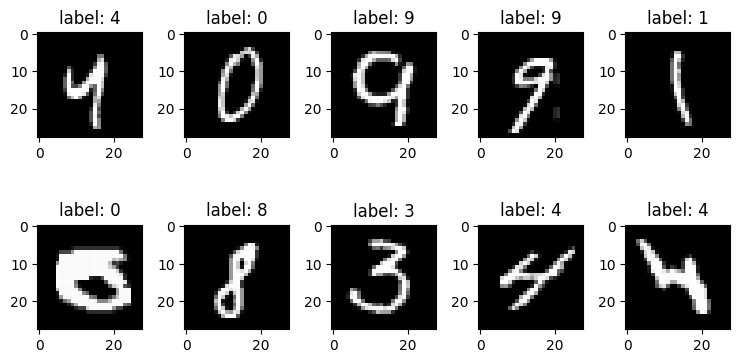

<function __main__.show_random_grid(x_train, y_train, num_row, num_col)>

In [13]:
#display dataset 
def show_random_grid(x_train,y_train,num_row,num_col):
    num = num_row*num_col    #to recognized the number from 1 to 10 

    image = x_train[:num].reshape(num,28,28) 
    label = y_train[:num] 

    #plot image 
    fig, axes =plt.subplots(num_row,num_col, figsize=(1.5*num_col,2*num_row))
    for i in range(num):   #run from 1 to 10 
        ax = axes[i//num_col,i%num_col] #run from very columns like 4//5 = 0 , put in first row  , 8%5=1 put in 1st row 
        ax.imshow(image[i],cmap='grey') 
        ax.set_title('label: {}'.format(label[i])) 
    plt.tight_layout() 
    plt.show() 
    return show_random_grid 


show_random_grid(x_train,y_train,2,5) 
    

In [14]:
import numpy as np
import time

class NeuralNetwork():
  def __init__ (self, layer_sizes, layer_activation_functions, learning_rate, momentum, epochs, batch_size):
    # Used to map the activation functions to the correct function
    activation_functions_map = {
      'sigmoid': self._sigmoid,
      'relu': self._relu,
      'tanh': self._tanh,
      'softmax': self._softmax,
    }

    self.layer_sizes = layer_sizes
    self.layer_activation_functions = [ activation_functions_map[function] for function in layer_activation_functions ]
    self.learning_rate = learning_rate
    self.momentum = momentum
    self.epochs = epochs
    self.batch_size = batch_size


  def train(self,x_train,y_train):
    """Trains the network.

    Args:
        training_images (numpy.ndarray): The training images.
        training_labels (numpy.ndarray): The training labels.
    """

    print('Training the neural network...')

    # Initialize the weights and biases with random values to avoid local minima
    self.W = [] 
    self.B = []
    for layer in range(len(self.layer_sizes) - 1):
      self.W.append(0.1 * np.random.randn(self.layer_sizes[layer], self.layer_sizes[layer + 1]))
      self.B.append(np.zeros((1, self.layer_sizes[layer + 1])))

    # Interates over the epochs
    for epoch in range(self.epochs):
      start_time = time.time()

      # Trains in batches to speed up the training
      for batch_start in range(0,x_train.shape[0], self.batch_size):
        batch_images = x_train[batch_start:batch_start+self.batch_size]
        batch_labels = y_train[batch_start:batch_start+self.batch_size]

        # Forward pass
        hidden_layers = self._forward(batch_images)

        # Backward pass
        self._backpass(hidden_layers=hidden_layers, x_train=batch_images, y_train=batch_labels)

      end_time = time.time() - start_time
      print ('Epoch {}/{}, time: {:.2f}s, training accuracy: {:.2f}%'.format(epoch + 1, self.epochs, end_time, self.evaluate(x_train, y_train) * 100))

    print('Training complete!')


  def _forward (self,x_train):
    """Performs a forward pass through the network.

    Args:
        training_images (numpy.ndarray): The training images.
    Returns:
        output_layers (list): A list of the output layers of the network.
        
    """
    output_layers = [x_train]
    input = output_layers[0]

    for layer in range(len(self.layer_sizes) - 1):
      hidden_layer = self.layer_activation_functions[layer](np.dot(input, self.W[layer]) + self.B[layer])
      output_layers.append(hidden_layer)
      input = hidden_layer

    # output = self._softmax(scores)
    return output_layers


  def _backpass (self, hidden_layers,x_train,y_train):
    """Performs a backpass on the network.

    Args:
        hidden_layer1 (numpy.ndarray): The first hidden layer of the network.
        hidden_layer2 (numpy.ndarray): The second hidden layer of the network.
        hidden_layer2 (numpy.ndarray): The output layer of the network.
        training_images (numpy.ndarray): The training images.
        training_labels (numpy.ndarray): The training labels.
    """

    layers = hidden_layers

    # Calculates the deltas for the output layer to use in the backpropagation
    delta_weights = []
    delta_biases = []
    delta_hidden = []

    dscores = layers[-1]
    dscores[range(len(x_train)),y_train] -= 1
    dscores /= len(x_train)

    delta_hidden.append(dscores)

    # Performs the backpropagation on the hidden layers to calculate the deltas for the weights and biases
    for layer in reversed(range(len(layers) - 1)):
      delta_weights.insert(0, np.dot(layers[layer].T, delta_hidden[0]))
      delta_biases.insert(0, np.sum(delta_hidden[0], axis=0, keepdims=True))

      if layer == 0:
        break

      delta_hidden.insert(0, np.dot(delta_hidden[0], self.W[layer].T))
      delta_hidden[0][layers[layer] <= 0] = 0

    # Update delta weights with momentum.
    for layer in reversed(range(len(delta_weights))):
      delta_weights[layer] += self.momentum*self.W[layer]

    # Updates the network's weights and biases.
    for layer in range(len(delta_weights)):
      self.W[layer] += -self.learning_rate * delta_weights[layer]
      self.B[layer] += -self.learning_rate * delta_biases[layer]


  def predict(self, image):
    """Predicts the label of an image.

    Args:
        image (numpy.ndarray): The image to predict the label of.

    Returns:
        int: The predicted label.
    """

    outputs = self._forward(image)
    return np.argmax(outputs[-1])


  def evaluate (self, validation_images, validation_labels):
    """Evaluates the accuracy of the network on a validation set.

    Args:
        validation_images (numpy.ndarray): The validation images.
        validation_labels (numpy.ndarray): The validation labels.

    Returns:
        accuracy (float): The accuracy of the network on the validation set.
    """

    outputs = self._forward(validation_images)

    count = 0
    for i in range(len(validation_images)):
      if np.argmax(outputs[-1][i]) == validation_labels[i]:
        count += 1
    return count / len(validation_images)


  def _sigmoid(self, x, derivative=False):
    """Computes the sigmoid function.

    Args:
        x (numpy.ndarray): The input to the sigmoid function.
        derivative (bool): Whether to compute the derivative of the sigmoid function or not.

    Returns:
        _type_: _description_
    """
    if derivative:
      return x * (1 - x)
    return 1 / (1 + np.exp(-x))


  def _relu(self, x, derivative=False):
    """Computes the rectified linear unit.
    
    Args:
        x (numpy.ndarray): The input data.
        derivative (bool): Whether to compute the derivative of the relu or not.
        
    Returns:
        numpy.ndarray: The relu of the input data.
    """    

    if derivative:
      return np.where(x > 0, 1, 0)
    return np.maximum(0, x)


  def _tanh(self, x, derivative=False):
    """Computes the hyperbolic tangent function.

    Args:
        x (numpy.ndarray): The input to the tanh function.
        derivative (bool): Whether to compute the derivative of the tanh function or not.

    Returns:
        _type_: _description_
    """
    if derivative:
      return 1 - np.power(x, 2)
    return np.tanh(x)


  def _softmax(self, x, derivative=False):
    """Computes the softmax activation function.
    
    Args:
        x (numpy.ndarray): The input data.
        derivative (bool): Whether to compute the derivative of the softmax or not.
        
    Returns:
        numpy.ndarray: The softmax of the input data.
    """

    if derivative:
      return x * (1 - x)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

In [15]:
print(f'Starting model 1...')
np.random.seed(0)
nn = NeuralNetwork([784, 64, 10], ['tanh', 'tanh', 'tanh'], 0.1, 1e-3, 10, 128)
nn.train(x_train,y_train)
print('Model 1 complete!')
print('Model 1 testing set accuracy: {:.2f}%'.format(nn.evaluate(x_train, y_train) * 100))

Starting model 1...
Training the neural network...
Epoch 1/10, time: 0.16s, training accuracy: 75.60%
Epoch 2/10, time: 0.16s, training accuracy: 79.20%
Epoch 3/10, time: 0.16s, training accuracy: 80.36%
Epoch 4/10, time: 0.15s, training accuracy: 81.41%
Epoch 5/10, time: 0.15s, training accuracy: 82.05%
Epoch 6/10, time: 0.15s, training accuracy: 82.77%
Epoch 7/10, time: 0.15s, training accuracy: 83.69%
Epoch 8/10, time: 0.15s, training accuracy: 84.33%
Epoch 9/10, time: 0.15s, training accuracy: 84.62%
Epoch 10/10, time: 0.15s, training accuracy: 84.84%
Training complete!
Model 1 complete!
Model 1 testing set accuracy: 84.84%


In [16]:
# Model 3
print(f'Starting model 3...')
np.random.seed(0)
nn = NeuralNetwork([784, 256, 64, 10], ['relu', 'relu', 'relu', 'softmax'], 0.1, 1e-3, 10, 128)
nn.train(x_train,y_train)
print('Model 3 complete!')
print('Model 3 testing set accuracy: {:.2f}%'.format(nn.evaluate(x_train, y_train) * 100))

Starting model 3...
Training the neural network...
Epoch 1/10, time: 0.53s, training accuracy: 88.04%
Epoch 2/10, time: 0.51s, training accuracy: 91.23%
Epoch 3/10, time: 0.52s, training accuracy: 92.81%
Epoch 4/10, time: 0.53s, training accuracy: 93.74%
Epoch 5/10, time: 0.52s, training accuracy: 94.46%
Epoch 6/10, time: 0.50s, training accuracy: 95.01%
Epoch 7/10, time: 0.51s, training accuracy: 95.36%
Epoch 8/10, time: 0.51s, training accuracy: 95.80%
Epoch 9/10, time: 0.50s, training accuracy: 96.13%
Epoch 10/10, time: 0.55s, training accuracy: 96.36%
Training complete!
Model 3 complete!
Model 3 testing set accuracy: 96.36%


In [20]:
kaggle_test_df = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\mnist\test.csv') 
kaggle_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
kaggle_test_df = kaggle_test_df.values/255.0

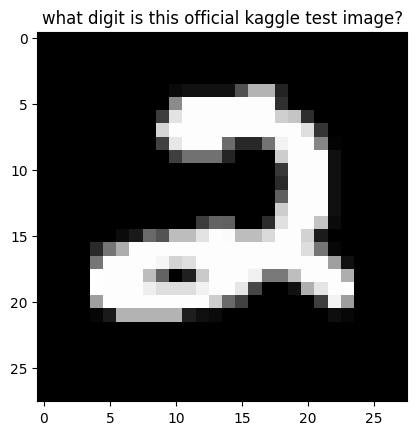

In [23]:
sample_index = 0 
single_kaggle_image = kaggle_test_df[sample_index] 

plt.imshow(single_kaggle_image.reshape(28,28), cmap='gray' ) 
plt.title("what digit is this official kaggle test image?") 
plt.show() 

In [28]:
predict_label = nn.predict(single_kaggle_image) 
print(predict_label)

2
